# Experiment 4: Air Track II — Newton's Second Law

**Team name:** Labradors  
**Team members:** Aidan, Qais, Morgan, Georg
**Lab dates:** October 5 and October 19, 2026

## Objectives

- Measure the acceleration of an air-track cart with two photogates.
- Predict the acceleration and string tension for a cart–hanger system.
- Test Newton's second law by graphing tension versus measured acceleration.
- Compare the fitted slope with the independently measured cart mass.
- Estimate random and measurement uncertainties and identify systematic effects.

> **Submission:** One notebook is submitted per team through Scholar. Each person also submits the private Individual Team Effort Report. Do not put individual reports in the public GitHub repository.


# Safety and apparatus

- Keep paper under a cart whenever the blower is off. Never slide a cart on an unpowered track.
- Turn the blower on fully before releasing the cart.
- Keep fingers, hair, and loose clothing away from the pulley and string.
- Position the gates so the cart clears both before the hanger reaches the floor.
- Catch the cart before it strikes the end stop or rebounds through a gate.
- Add cart masses symmetrically and secure them.

**Apparatus:** air track and blower, cart and flag, pulley and string, mass hanger and slotted masses, two photogates, PASCO 850 interface with Capstone, balance, ruler or calipers, and paper pads.


# Physical model

Let $m_c$ be the total moving cart mass and $m_h$ the total hanging mass. Neglecting friction, pulley inertia, string mass, and air drag,

$$m_hg-T=m_ha, \qquad T=m_ca.$$

Thus,

$$a_{\rm pred}=\frac{m_hg}{m_c+m_h}, \qquad
T_{\rm pred}=\frac{m_cm_hg}{m_c+m_h}.$$

The two photogates measure velocities $v_1$ and $v_2$ at event times $t_1$ and $t_2$:

$$a_{\rm meas}=\frac{v_2-v_1}{t_2-t_1}.$$

For the cart alone, $T=m_ca$. Therefore, a graph of predicted tension versus measured acceleration should be linear, with a slope equal to the cart mass and an intercept consistent with zero.


# Experimental procedure

## Level and inspect the track

1. Disconnect the string, turn on the blower, and place the unloaded cart near the center.
2. Adjust the leveling feet until the cart shows no reproducible drift.
3. Reconnect the string. Check that the pulley rotates freely and the string is parallel to the track.
4. Verify that the cart, masses, hanger, and string can travel without collision.

## Configure the two photogates

1. Connect both gates to the PASCO 850 interface and configure each for a single flag and speed measurement.
2. Measure the flag length and enter that value in Capstone for both gates.
3. Adjust the gate heights so only the flag interrupts each beam.
4. Display the event time and velocity for each gate.
5. Pass the cart through both gates by hand and verify that each gate records one clean event.

## Collect data in the order represented below

Start with the light cart. For hanging-mass setup 1, collect five trials and enter them in its code cell. Run that cell and inspect the result before adding mass. Repeat for setups 2–5. Then add mass to the cart, measure the complete heavy-cart mass, and repeat the five hanging-mass setups in the second analysis section.

Release the cart without pushing it. Keep the release point and gate positions fixed within a cart-mass series. Preserve every trial; if one must be rejected, document the objective apparatus reason in the report rather than silently replacing it.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import P201_Functions as p201
except ImportError:
    %pip -q install P201_Functions
    import P201_Functions as p201

# REPLACE these example instrument values with the values used by your team.
flag_length = 0.0118       # m
u_flag_length = 0.0005     # m
u_time = 0.0001            # s; Capstone timing uncertainty
g = 9.805                  # m/s^2 in Newport News
u_g = 0.005                # m/s^2

pd.set_option("display.float_format", lambda x: f"{x:.5g}")


## Analysis helpers

These functions carry out the repeated calculations so that your work in each data-taking section is limited to entering masses and the five measured values of $v_1$, $t_1$, $v_2$, and $t_2$. You do not need to modify these functions.


In [14]:
def predicted_values(m_cart, u_m_cart, m_hang, u_m_hang):
    total = m_cart + m_hang
    a_pred = m_hang * g / total
    u_a_pred = np.sqrt(
        (-m_hang * g / total**2 * u_m_cart)**2
        + (m_cart * g / total**2 * u_m_hang)**2
        + (m_hang / total * u_g)**2
    )

    tension = m_cart * m_hang * g / total
    u_tension = np.sqrt(
        (m_hang**2 * g / total**2 * u_m_cart)**2
        + (m_cart**2 * g / total**2 * u_m_hang)**2
        + (m_cart * m_hang / total * u_g)**2
    )
    return a_pred, u_a_pred, tension, u_tension


def analyze_configuration(m_cart, u_m_cart, m_hang, u_m_hang, v1, t1, v2, t2):
    df = pd.DataFrame({"v1 (m/s)": v1, "t1 (s)": t1, "v2 (m/s)": v2, "t2 (s)": t2})
    if len(df) < 5:
        raise ValueError("Enter at least five trials for this hanging-mass setup.")
    if not (df["t2 (s)"] > df["t1 (s)"]).all():
        raise ValueError("Every t2 must be greater than t1.")

    dt = df["t2 (s)"] - df["t1 (s)"]
    dv = df["v2 (m/s)"] - df["v1 (m/s)"]
    df["a (m/s^2)"] = dv / dt

    # Capstone obtains v = flag_length / gate-block time. Infer each block time
    # from the reported velocity, then propagate flag-length and timing uncertainty.
    block1 = flag_length / df["v1 (m/s)"]
    block2 = flag_length / df["v2 (m/s)"]
    u_v1 = df["v1 (m/s)"] * np.sqrt((u_flag_length / flag_length)**2 + (u_time / block1)**2)
    u_v2 = df["v2 (m/s)"] * np.sqrt((u_flag_length / flag_length)**2 + (u_time / block2)**2)
    df["u_a, instrument (m/s^2)"] = np.sqrt(
        (u_v1 / dt)**2 + (u_v2 / dt)**2
        + (dv * u_time / dt**2)**2 + (dv * u_time / dt**2)**2
    )

    a_mean = df["a (m/s^2)"].mean()
    a_sem = df["a (m/s^2)"].std(ddof=1) / np.sqrt(len(df))
    u_instrument_mean = np.sqrt(np.sum(df["u_a, instrument (m/s^2)"]**2)) / len(df)
    u_a_mean = np.sqrt(a_sem**2 + u_instrument_mean**2)
    a_pred, u_a_pred, tension, u_tension = predicted_values(
        m_cart, u_m_cart, m_hang, u_m_hang
    )
    z = abs(a_mean - a_pred) / np.sqrt(u_a_mean**2 + u_a_pred**2)

    return {
        "data": df, "m_hang": m_hang, "u_m_hang": u_m_hang,
        "a_mean": a_mean, "u_a_mean": u_a_mean, "a_sem": a_sem,
        "a_pred": a_pred, "u_a_pred": u_a_pred,
        "tension": tension, "u_tension": u_tension, "z": z,
    }


def start_cart_series():
    global measured_a, u_measured_a, predicted_tension, u_predicted_tension, configuration_results
    measured_a, u_measured_a = [], []
    predicted_tension, u_predicted_tension = [], []
    configuration_results = []


def add_configuration(result):
    configuration_results.append(result)
    measured_a.append(result["a_mean"])
    u_measured_a.append(result["u_a_mean"])
    predicted_tension.append(result["tension"])
    u_predicted_tension.append(result["u_tension"])


def show_configuration(number, result):
    print(f"Hanging-mass setup {number}")
    print(result["data"])
    print(f"Measured acceleration = {result['a_mean']:.5f} ± {result['u_a_mean']:.5f} m/s²")
    print(f"Predicted acceleration = {result['a_pred']:.5f} ± {result['u_a_pred']:.5f} m/s²")
    print(f"Predicted tension = {result['tension']:.5f} ± {result['u_tension']:.5f} N")
    print(f"Compatibility z = {result['z']:.2f}")


# Part I — Light cart

Measure the complete moving mass of the cart, including its flag. Enter one hanging-mass configuration at a time as you collect it. Run each cell before changing the hanging mass so that mistakes can be found while the apparatus is still configured.


In [19]:
# Light-cart setup
cart_mass = 0.20013       # kg; REPLACE with complete light-cart mass
u_cart_mass = 0.000005    # kg; REPLACE with balance uncertainty
start_cart_series()


## Light cart — hanging-mass setup 1

Collect and enter five trials before changing the hanging mass.


In [20]:
# Hanging-mass setup 1
m_hang = 0.01       # kg; REPLACE with total hanger + added mass
u_m_hang = 0.005   # kg; REPLACE with balance uncertainty

# Enter the five trials in the order collected.
v1 = [0.33, 0.37, 0.38, 0.34, 0.28]   # m/s, gate 1
t1 = [1.437, 0.90, 0.888, 0.907, 0.649]   # s, gate 1 event time
v2 = [0.88, 0.91, 0.92, 0.90, 0.88]   # m/s, gate 2
t2 = [2.555, 1.956, 1.939, 2.004, 1.817]   # s, gate 2 event time

result_1 = analyze_configuration(cart_mass, u_cart_mass, m_hang, u_m_hang, v1, t1, v2, t2)
add_configuration(result_1)
show_configuration(1, result_1)


Hanging-mass setup 1
   v1 (m/s)  t1 (s)  v2 (m/s)  t2 (s)  a (m/s^2)  u_a, instrument (m/s^2)
0      0.33   1.437      0.88   2.555    0.49195                  0.03611
1      0.37     0.9      0.91   1.956    0.51136                 0.039989
2      0.38   0.888      0.92   1.939     0.5138                 0.040724
3      0.34   0.907       0.9   2.004    0.51048                 0.037695
4      0.28   0.649      0.88   1.817     0.5137                 0.033975
Measured acceleration = 0.50826 ± 0.01739 m/s²
Predicted acceleration = 0.46662 ± 0.22221 m/s²
Predicted tension = 0.09338 ± 0.04447 N
Compatibility z = 0.19


## Light cart — hanging-mass setup 2

Collect and enter five trials before changing the hanging mass.


In [21]:
# Hanging-mass setup 2
m_hang = 0.00682       # kg; REPLACE with total hanger + added mass
u_m_hang = 0.000005   # kg; REPLACE with balance uncertainty

# Enter the five trials in the order collected.
v1 = [0.31 , 0.29, 0.25, 0.26, 0.24]   # m/s, gate 1
t1 = [0.795, 0.510, 0.538, 0.382, 0.461]   # s, gate 1 event time
v2 = [0.75, 0.75, 0.73, 0.73, 0.73]   # m/s, gate 2
t2 = [2.079, 1.821, 1.913, 1.751, 1.872]   # s, gate 2 event time

result_2 = analyze_configuration(
    cart_mass, u_cart_mass, m_hang, u_m_hang, v1, t1, v2, t2
)
add_configuration(result_2)
show_configuration(2, result_2)


Hanging-mass setup 2
   v1 (m/s)  t1 (s)  v2 (m/s)  t2 (s)  a (m/s^2)  u_a, instrument (m/s^2)
0      0.31   0.795      0.75   2.079    0.34268                 0.027045
1      0.29    0.51      0.75   1.821    0.35088                 0.026249
2      0.25   0.538      0.73   1.913    0.34909                 0.024008
3      0.26   0.382      0.73   1.751    0.34332                 0.024215
4      0.24   0.461      0.73   1.872    0.34727                   0.0233
Measured acceleration = 0.34665 ± 0.01130 m/s²
Predicted acceleration = 0.32312 ± 0.00028 m/s²
Predicted tension = 0.06467 ± 0.00006 N
Compatibility z = 2.08


## Light cart — hanging-mass setup 3

Collect and enter five trials before changing the hanging mass.


In [22]:
# Hanging-mass setup 3
m_hang = 0.0038       # kg; REPLACE with total hanger + added mass
u_m_hang = 0.00005   # kg; REPLACE with balance uncertainty

# Enter the five trials in the order collected.
v1 = [0.21, 0.23, 0.22, 0.21, 0.22]   # m/s, gate 1
t1 = [1.024, 0.828, 1.181, 1.037, 1.252]   # s, gate 1 event time
v2 = [0.56, 0.56, 0.56, 0.55, 0.55]   # m/s, gate 2
t2 = [2.793, 2.549, 2.937, 2.827, 3.013]   # s, gate 2 event time

result_3 = analyze_configuration(
    cart_mass, u_cart_mass, m_hang, u_m_hang, v1, t1, v2, t2
)
add_configuration(result_3)
show_configuration(3, result_3)


Hanging-mass setup 3
   v1 (m/s)  t1 (s)  v2 (m/s)  t2 (s)  a (m/s^2)  u_a, instrument (m/s^2)
0      0.21   1.024      0.56   2.793    0.19785                 0.014406
1      0.23   0.828      0.56   2.549    0.19175                 0.014987
2      0.22   1.181      0.56   2.937    0.19362                 0.014599
3      0.21   1.037      0.55   2.827    0.18994                 0.014011
4      0.22   1.252      0.55   3.013    0.18739                  0.01433
Measured acceleration = 0.19211 ± 0.00671 m/s²
Predicted acceleration = 0.18270 ± 0.00236 m/s²
Predicted tension = 0.03656 ± 0.00047 N
Compatibility z = 1.32


## Light cart — hanging-mass setup 4

Collect and enter five trials before changing the hanging mass.


In [23]:
# Hanging-mass setup 4
m_hang = 0.0166       # kg; REPLACE with total hanger + added mass
u_m_hang = 0.00005   # kg; REPLACE with balance uncertainty

# Enter the five trials in the order collected.
v1 = [0.38, 0.30, 0.39, 0.35, 0.41]   # m/s, gate 1
t1 = [0.267, 0.548, 0.606, 0.168, 1.14]   # s, gate 1 event time
v2 = [1.13, 1.11, 1.13, 1.11, 1.14]   # m/s, gate 2
t2 = [1.164, 1.504, 1.497, 1.091, 1.439]   # s, gate 2 event time

result_4 = analyze_configuration(
    cart_mass, u_cart_mass, m_hang, u_m_hang, v1, t1, v2, t2
)
add_configuration(result_4)
show_configuration(4, result_4)


Hanging-mass setup 4
   v1 (m/s)  t1 (s)  v2 (m/s)  t2 (s)  a (m/s^2)  u_a, instrument (m/s^2)
0      0.38   0.267      1.13   1.164    0.83612                 0.057611
1       0.3   0.548      1.11   1.504    0.84728                 0.052127
2      0.39   0.606      1.13   1.497    0.83053                  0.05815
3      0.35   0.168      1.11   1.091     0.8234                 0.054627
4      0.41    1.14      1.14   1.439     2.4415                  0.17566
Measured acceleration = 1.15576 ± 0.32413 m/s²
Predicted acceleration = 0.75099 ± 0.00212 m/s²
Predicted tension = 0.15030 ± 0.00042 N
Compatibility z = 1.25


## Light cart — hanging-mass setup 5

Collect and enter five trials before changing the hanging mass.


In [24]:
# Hanging-mass setup 5
m_hang = 0.0196       # kg; REPLACE with total hanger + added mass
u_m_hang = 0.00005   # kg; REPLACE with balance uncertainty

# Enter the five trials in the order collected.
v1 = [0.39, 0.44, 0.47, 0.38, 0.39]   # m/s, gate 1
t1 = [0.394, 0.636, 0.647, 0.608, 0.684]   # s, gate 1 event time
v2 = [1.20, 1.23, 1.21, 1.19, 1.20]   # m/s, gate 2
t2 = [1.247, 1.448, 1.452, 1.466, 1.534]   # s, gate 2 event time

result_5 = analyze_configuration(
    cart_mass, u_cart_mass, m_hang, u_m_hang, v1, t1, v2, t2
)
add_configuration(result_5)
show_configuration(5, result_5)


Hanging-mass setup 5
   v1 (m/s)  t1 (s)  v2 (m/s)  t2 (s)  a (m/s^2)  u_a, instrument (m/s^2)
0      0.39   0.394       1.2   1.247    0.94959                 0.064309
1      0.44   0.636      1.23   1.448    0.97291                 0.070003
2      0.47   0.647      1.21   1.452    0.91925                 0.070083
3      0.38   0.608      1.19   1.466    0.94406                 0.063275
4      0.39   0.684       1.2   1.534    0.95294                 0.064536
Measured acceleration = 0.94775 ± 0.03097 m/s²
Predicted acceleration = 0.87461 ± 0.00208 m/s²
Predicted tension = 0.17504 ± 0.00042 N
Compatibility z = 2.36


## Light-cart fit and comparison

Run this after all five light-cart configurations. `P201_Functions` performs the same course-standard linear fit used in the other PHYS 201L and PHYS 202L notebooks.


Light-cart fit: Coefficients (from curve_fit)
[0.01785398 0.13508594]
Light-cart fit: Covariance Matrix (from curve_fit)
[[ 2.70685838e-08 -6.51846710e-08]
 [-6.51846710e-08  1.76807193e-07]]

Light-cart fit: Final Result: y = (0.13509 +/- 0.00042) x + (0.01785 +/- 0.00016)



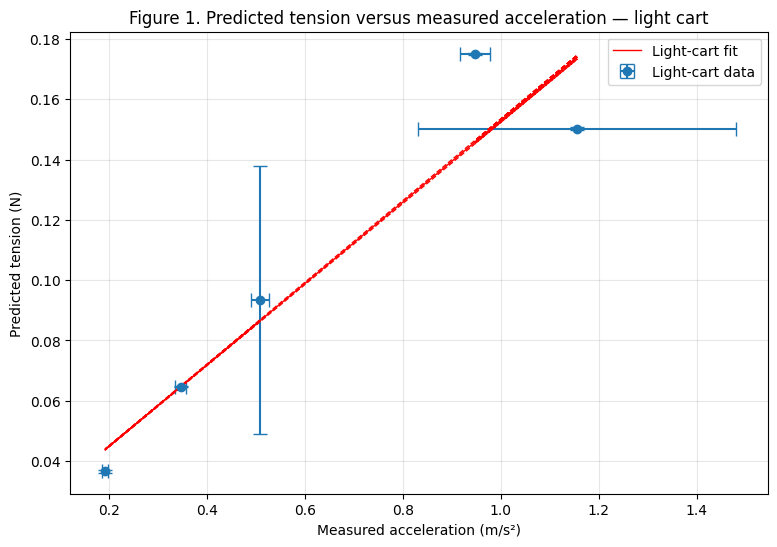

Fit slope = 0.13509 ± 0.00042 kg
Measured cart mass = 0.20013 ± 0.00001 kg
Slope / measured mass = 0.675
Percent difference = 32.50%
Fit intercept = 0.01785 ± 0.00016 N


In [25]:
x_light = np.asarray(measured_a)
u_x_light = np.asarray(u_measured_a)
y_light = np.asarray(predicted_tension)
u_y_light = np.asarray(u_predicted_tension)

plt.figure(figsize=(9, 6))
plt.errorbar(x_light, y_light, xerr=u_x_light, yerr=u_y_light, fmt="o", capsize=5, label="Light-cart data")
b_light, slope_light, u_b_light, u_slope_light = p201.linear_fit_plot_errors(
    x_light, y_light, u_y_light, plt, labelstring="Light-cart fit"
)
plt.title("Figure 1. Predicted tension versus measured acceleration — light cart")
plt.xlabel("Measured acceleration (m/s²)")
plt.ylabel("Predicted tension (N)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

ratio_light = slope_light / cart_mass
percent_difference_light = 100 * abs(slope_light - cart_mass) / cart_mass
print(f"Fit slope = {slope_light:.5f} ± {u_slope_light:.5f} kg")
print(f"Measured cart mass = {cart_mass:.5f} ± {u_cart_mass:.5f} kg")
print(f"Slope / measured mass = {ratio_light:.3f}")
print(f"Percent difference = {percent_difference_light:.2f}%")
print(f"Fit intercept = {b_light:.5f} ± {u_b_light:.5f} N")


## Light-cart checkpoint

- Does the fitted slope agree with the measured cart mass within uncertainty?
- Is the intercept consistent with zero?
- Do the individual measured accelerations agree with their predictions?
- If not, inspect the track level, pulley, string, gate triggering, and release technique before adding cart mass.

**Team response:** REPLACE WITH YOUR QUANTITATIVE CHECKPOINT.


# Part II — Heavy cart

Add mass symmetrically to the cart and remeasure the complete moving mass. Repeat the same five hanging-mass configurations. Keep the light- and heavy-cart results separate because each series tests a different expected slope.


In [ ]:
# Heavy-cart setup
cart_mass = 0.30061       # kg; REPLACE with complete heavy-cart mass
u_cart_mass = 0.000005    # kg; REPLACE with balance uncertainty
start_cart_series()


## Heavy cart — hanging-mass setup 1

Collect and enter five trials before changing the hanging mass.


In [ ]:
# Hanging-mass setup 1
m_hang = 0.00194       # kg; REPLACE with total hanger + added mass
u_m_hang = 0.000005   # kg; REPLACE with balance uncertainty

# Enter the five trials in the order collected.
v1 = [0.09, 0.07, 0.07, 0.08, 0.08]   # m/s, gate 1
t1 = [2.824, 4.228, 7.096, 2.298, 2.323]   # s, gate 1 event time
v2 = [0.23, 0.23, 0.22, 0.23, 0.23]   # m/s, gate 2
t2 = [5.441, 6.97, 9.875, 4.977, 4.978]   # s, gate 2 event time

result_1 = analyze_configuration(
    cart_mass, u_cart_mass, m_hang, u_m_hang, v1, t1, v2, t2
)
add_configuration(result_1)
show_configuration(1, result_1)


## Heavy cart — hanging-mass setup 2

Collect and enter five trials before changing the hanging mass.


In [ ]:
# Hanging-mass setup 2
m_hang = 0.00288       # kg; REPLACE with total hanger + added mass
u_m_hang = 0.000005   # kg; REPLACE with balance uncertainty

# Enter the five trials in the order collected.
v1 = [0.11, 0.1, 0.1, 0.09, 0.1]   # m/s, gate 1
t1 = [2.25, 2.381, 2.364, 2.561, 2.019]   # s, gate 1 event time
v2 = [0.3, 0.29, 0.29, 0.29, 0.29]   # m/s, gate 2
t2 = [4.283, 4.493, 4.463, 4.681, 4.103]   # s, gate 2 event time

result_2 = analyze_configuration(
    cart_mass, u_cart_mass, m_hang, u_m_hang, v1, t1, v2, t2
)
add_configuration(result_2)
show_configuration(2, result_2)


## Heavy cart — hanging-mass setup 3

Collect and enter five trials before changing the hanging mass.


In [ ]:
# Hanging-mass setup 3
m_hang = 0.00481       # kg; REPLACE with total hanger + added mass
u_m_hang = 0.000005   # kg; REPLACE with balance uncertainty

# Enter the five trials in the order collected.
v1 = [0.17, 0.15, 0.13, 0.13, 0.14]   # m/s, gate 1
t1 = [2.443, 1.741, 1.869, 2.452, 2.376]   # s, gate 1 event time
v2 = [0.4, 0.4, 0.39, 0.39, 0.39]   # m/s, gate 2
t2 = [3.928, 3.271, 3.444, 4.027, 3.928]   # s, gate 2 event time

result_3 = analyze_configuration(
    cart_mass, u_cart_mass, m_hang, u_m_hang, v1, t1, v2, t2
)
add_configuration(result_3)
show_configuration(3, result_3)


## Heavy cart — hanging-mass setup 4

Collect and enter five trials before changing the hanging mass.


In [ ]:
# Hanging-mass setup 4
m_hang = 0.00973       # kg; REPLACE with total hanger + added mass
u_m_hang = 0.000005   # kg; REPLACE with balance uncertainty

# Enter the five trials in the order collected.
v1 = [0.18, 0.22, 0.23, 0.2, 0.2]   # m/s, gate 1
t1 = [1.244, 1.919, 0.934, 1.188, 1.545]   # s, gate 1 event time
v2 = [0.56, 0.57, 0.57, 0.56, 0.56]   # m/s, gate 2
t2 = [2.345, 2.981, 1.974, 2.276, 2.632]   # s, gate 2 event time

result_4 = analyze_configuration(
    cart_mass, u_cart_mass, m_hang, u_m_hang, v1, t1, v2, t2
)
add_configuration(result_4)
show_configuration(4, result_4)


## Heavy cart — hanging-mass setup 5

Collect and enter five trials before changing the hanging mass.


In [ ]:
# Hanging-mass setup 5
m_hang = 0.01955       # kg; REPLACE with total hanger + added mass
u_m_hang = 0.000005   # kg; REPLACE with balance uncertainty

# Enter the five trials in the order collected.
v1 = [0.31, 0.27, 0.29, 0.28, 0.3]   # m/s, gate 1
t1 = [0.963, 1.21, 1.097, 1.107, 1.075]   # s, gate 1 event time
v2 = [0.8, 0.78, 0.79, 0.79, 0.79]   # m/s, gate 2
t2 = [1.713, 1.983, 1.853, 1.871, 1.828]   # s, gate 2 event time

result_5 = analyze_configuration(
    cart_mass, u_cart_mass, m_hang, u_m_hang, v1, t1, v2, t2
)
add_configuration(result_5)
show_configuration(5, result_5)


## Heavy-cart fit and comparison

Run this after all five heavy-cart configurations.


In [ ]:
x_heavy = np.asarray(measured_a)
u_x_heavy = np.asarray(u_measured_a)
y_heavy = np.asarray(predicted_tension)
u_y_heavy = np.asarray(u_predicted_tension)

plt.figure(figsize=(9, 6))
plt.errorbar(x_heavy, y_heavy, xerr=u_x_heavy, yerr=u_y_heavy, fmt="o", capsize=5, label="Heavy-cart data")
b_heavy, slope_heavy, u_b_heavy, u_slope_heavy = p201.linear_fit_plot_errors(
    x_heavy, y_heavy, u_y_heavy, plt, labelstring="Heavy-cart fit"
)
plt.title("Figure 2. Predicted tension versus measured acceleration — heavy cart")
plt.xlabel("Measured acceleration (m/s²)")
plt.ylabel("Predicted tension (N)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

ratio_heavy = slope_heavy / cart_mass
percent_difference_heavy = 100 * abs(slope_heavy - cart_mass) / cart_mass
print(f"Fit slope = {slope_heavy:.5f} ± {u_slope_heavy:.5f} kg")
print(f"Measured cart mass = {cart_mass:.5f} ± {u_cart_mass:.5f} kg")
print(f"Slope / measured mass = {ratio_heavy:.3f}")
print(f"Percent difference = {percent_difference_heavy:.2f}%")
print(f"Fit intercept = {b_heavy:.5f} ± {u_b_heavy:.5f} N")


## Heavy-cart checkpoint

- Does the fitted slope agree with the measured heavy-cart mass within uncertainty?
- Is the intercept consistent with zero?
- Did adding cart mass change the slope in the expected direction?
- Are any disagreements systematic across both series?

**Team response:** REPLACE WITH YOUR QUANTITATIVE CHECKPOINT.


# Your lab report

Replace the prompts below with a coherent scientific report. Do not leave instructional text or example values in the submitted notebook.

## Experimental procedure

Describe what your team actually did, including track leveling, photogate configuration, flag measurement, cart and hanging masses, release method, uncertainty choices, safety practices, and troubleshooting.

## Data and analysis

Present the light- and heavy-cart results separately. Include raw trial tables, measured and predicted accelerations with uncertainties, compatibility values, both tension-versus-acceleration figures, fitted slopes and intercepts, and quantitative slope-to-mass comparisons.

Every figure needs a number, descriptive caption, labeled axes, and units. Explain why repeated-trial scatter and instrument precision both matter.

## Results and conclusion

1. Do the measured accelerations agree with the cart–hanger model? Cite numerical evidence.
2. Do the two fitted slopes agree with their independently measured cart masses?
3. Are the intercepts consistent with zero? Explain their physical meaning.
4. Identify the dominant random uncertainty and the most plausible systematic error.
5. Discuss track tilt, pulley friction/inertia, string mass, release technique, and gate alignment where relevant.
6. State one specific improvement that would most reduce uncertainty or bias.

**Team report:** REPLACE WITH YOUR PROCEDURE, DATA DISCUSSION, AND CONCLUSION.


# Questions

1. Calculate the acceleration of a $0.5\ \mathrm{kg}$ cart with a $1.0\ \mathrm{kg}$ hanging mass.
2. Calculate the acceleration of a $1.0\ \mathrm{kg}$ cart with a $0.5\ \mathrm{kg}$ hanging mass.
3. Calculate the acceleration uncertainty for each case using realistic mass uncertainties. Which is lower, and why?
4. Does a photogate measure the cart's true instantaneous velocity? Explain what finite flag length means physically.

**Team responses:** REPLACE WITH CALCULATIONS AND EXPLANATIONS.


# Submission checklist

- [ ] Replace the team-identification placeholders.
- [ ] Replace both cart masses, every hanging mass, every instrument uncertainty, and all trial arrays with team data.
- [ ] Run every data cell immediately after its corresponding apparatus configuration.
- [ ] Complete both quantitative checkpoints, the report, and the questions.
- [ ] Run **Runtime → Run all** and confirm that all cells finish without errors.
- [ ] Confirm that both tables and both figures are visible with correct units and captions.
- [ ] Remove all “REPLACE” prompts.
- [ ] Save to the notebook's original path in the team fork and verify the saved outputs on GitHub.
- [ ] Submit that GitHub notebook URL to **Lab 4 — Team Notebook Submission** in Scholar.
- [ ] Each student privately submits the Individual Team Effort Report in Scholar.
